# Instalando

<center>
 <img src="https://raw.githubusercontent.com/serengil/deepface/master/icon/deepface-icon-labeled.png" width="150">
 </center>

 Aqui usamos o [deepface](https://github.com/serengil/deepface)

Ele depende das biblioteca `tf-keras`

Certainly! Let's delve deeper into the workings of transformers,
focusing on each component and providing a more detailed
explanation.

### Overview of Transformer Architecture

The transformer architecture is designed to handle sequential
data efficiently by leveraging self-attention mechanisms. This
approach allows it to process sequences in parallel, which can be
much faster than traditional recurrent neural networks (RNNs).

#### Key Components:

1. **Self-Attention Mechanism**:
   - **Scaled Dot-Product Attention**:
     $$
     \text{Attention}(Q, K, V) =
\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
     $$
     Here, \( Q \), \( K \), and \( V \) are the query, key, and
value matrices, respectively. The dot product is scaled by the
square root of the embedding dimension to prevent gradients from
vanishing or exploding.

2. **Multi-Head Attention**:
   - To capture different aspects of the input sequence, multiple
attention heads are used in parallel.
   - Each head processes a subset of the full feature space and
combines their results using concatenation followed by linear
projections.
     $$
     \text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1,
\ldots, \text{head}_h)W^O
     $$
   - Each head computes its own attention and the outputs are
concatenated before being linearly transformed.

3. **Positional Encoding**:
   - Since transformers lack recurrent connections, positional
information is crucial.
   - Positional encodings are added to the input embeddings to
provide this context.
   - Common methods include sinusoidal positional encoding or
learned positional embeddings.

4. **Feed-Forward Networks (FFNs)**:
   - These networks process each position independently after the
self-attention mechanism.
   - They typically consist of two linear layers with a
non-linear activation function (like ReLU) in between.
     $$
     FFN(x) = W_2 \cdot \text{ReLU}(W_1 \cdot x + b_1) + b_2
     $$

5. **Normalization Layers**:
   - Layer normalization is used to stabilize and speed up
training by normalizing the inputs across features.
   - It ensures that the data passed through each layer has a
consistent mean and variance.

6. **Encoder-Decoder Structure**:
   - **Encoder**: A stack of N identical layers, each with
self-attention mechanisms followed by feed-forward networks.
   - **Decoder**: Similar to the encoder but also includes
cross-attention (where it attends to the output from the encoder)
to generate coherent sequences.

### Detailed Explanation

#### 1. Input Embedding
- Each word in the input sequence is converted into a dense
vector using an embedding layer.
- The embeddings capture semantic and syntactic information about
the words.

#### 2. Positional Encoding
- Positional encodings are added to the embeddings to provide
positional context.
- For example, if $ x $ represents the position of a word in
the sequence:
  $$
  P(x) = \begin{cases}
  \sin\left(\frac{x}{10000^{2i/d}}\right), & \text{if } i \mod 2
= 0 \\
  \cos\left(\frac{x}{10000^{2(i-1)/d}}\right), & \text{if } i
\mod 2 = 1
  \end{cases}
  $$
  where \( d \) is the dimensionality of the word embedding.

#### 3. Self-Attention Mechanism
- The self-attention mechanism allows each token to attend to all
other tokens in the sequence.
- The key steps are:
  - Compute queries, keys, and values from the input embeddings.
  - Calculate attention scores using scaled dot-product
attention.
  - Apply a softmax function to these scores to get
normalized attention weights.
  - Weighted sum of the value vectors based on the attention
scores.

#### 4. Multi-Head Attention
- Multiple heads are used in parallel to capture different
aspects of the input sequence:
  $$
  \text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1,
\ldots, \text{head}_h)W^O
  $$
  - Each head computes its own attention and concatenates their
results.
- Linear projections are used to combine the outputs of all
heads.

#### 5. Feed-Forward Networks (FFNs)
- FFNs process each position independently after self-attention:
  $$
  FFN(x) = W_2 \cdot \text{ReLU}(W_1 \cdot x + b_1) + b_2
  $$
- These networks introduce non-linearities and allow the model to
capture complex patterns.

#### 6. Encoder Stack
- Multiple layers of the encoder are stacked:
  - Each layer consists of self-attention followed by
feed-forward networks.
  - Residual connections are used between each layer and the
normalization layer:
    \[
    x_{\text{out}} = \text{LayerNorm}(x + \text{EncoderBlock}(x))
    \]
  - Here, \( \text{EncoderBlock} \) represents a combination of
self-attention and feed-forward networks.

# Baixando dados

Uma boa forma de baixar dados no colab é subir as informações em algum lugar
que deixe baixar de forma acessível como no [github](https://github.com).

In [ ]:
# Baixar

!wget https://github.com/caiohamamuraIFSP/2024FIC_AI/raw/refs/heads/main/bd.zip

# Descompactar

!unzip bd.zip

--2025-05-22 00:00:22--  https://github.com/caiohamamuraIFSP/2024FIC_AI/raw/refs/heads/main/bd.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/caiohamamuraIFSP/2024FIC_AI/refs/heads/main/bd.zip [following]
--2025-05-22 00:00:22--  https://raw.githubusercontent.com/caiohamamuraIFSP/2024FIC_AI/refs/heads/main/bd.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2526245 (2.4M) [application/zip]
Saving to: ‘bd.zip’

bd.zip              100%[===================>]   2.41M  --.-KB/s    in 0.05s   

2025-05-22 00:00:23 (51.1 MB/s) - ‘bd.zip’ saved [2526245/2526245]

Archive:  bd.zip
   creating: b

In [ ]:
%pip install pyopenssl --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: pyopenssl
    Found existing installation: pyOpenSSL 24.2.1
    Uninstalling pyOpenSSL-24.2.1:
      Successfully uninstalled pyOpenSSL-24.2.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pydrive2 1.21.3 requires pyOpenSSL<=24.2.1,>=19.1.0, but you have pyopenssl 25.1.0 which is incompatible.


In [ ]:
%pip install deepface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 81.8 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=23871307270e3c8f55223321b02cb7051ac5aa0f561ad8681480209fbe94f255
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire


In [ ]:
from deepface import DeepFace

25-05-22 00:05:48 - Directory /root/.deepface has been created
25-05-22 00:05:48 - Directory /root/.deepface/weights has been created


In [ ]:
%pip install ultralytics --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.6 MB/s eta 0:00:00


# Modelos

Esses são os dois modelos mais famosos disponíveis

## [VGG-Face](https://www.robots.ox.ac.uk/~vgg/publications/2015/Parkhi15/)

[VGG](https://paperswithcode.com/method/vgg) é uma famosa rede CNN de 2014.
Essa aqui foi treinada no conjunto de dados LFW (labelled faces in the wild)
que contém 13.233 imagens de rostos da internet de 5.749 pessoas diferentes,
sendo que 1.680 destas possuem duas ou mais imagens.

<center>
<img src="https://production-media.paperswithcode.com/methods/vgg_7mT4DML.png">
</center>

Aqui tiramos a última camada de 1000 classes e ficamos com um `embedding` de 4096 valores.

## [FaceNet](https://arxiv.org/abs/1503.03832)


<center>
<img src="https://miro.medium.com/v2/resize:fit:1400/1*PaxDM5QUt8ZzUgCo2dzf4w.png">
</center>

A `FaceNet` também utiliza uma CNN como base, o que ela inovou foi na forma como a rede é treinada. Em vez de treinar a rede para classificar pessoas genéricas em classes, a `FaceNet` pode ser treinada diretamente nas pessoas de interesse sem precisar ser no modelo `classificação`.

Lembre que para treinar basta ter uma função de `Loss`. Nesse eles rodam a rede três vezes:

1. a âncora (A): foto de referência da pessoa
1. positiva (P): outra foto da **mesma pessoa** (de preferência bem diferente da original, mais nova, mais velha, outro corte de cabelo, barba, óculos, etc.).
1. negativa (N): foto de **outra pessoa**

Basta calcular a diferença entre a âncora e as duas outras fotos:

1. $ D(A, P) $: diferença entre âncora e positiva
1. $ D(A, N) $ : diferença entre âncora e negativa

A perda final é definida como:

$$ Loss =  D(A, P) - D(A, N) $$

Isso significa que se âncora e positiva ($ D(A, P) $) forem idênticas, a perda seria 0, mas se a diferença entre a âncora e negativa ($ D(A, N) $) for 1, a perda vai ser $ 0 - 1 = -1 $. Ou seja é possível ter perda inclusive negativa.

Lembre `Loss` quanto menor é melhor, então quanto mais negativo melhor, o que faz sentido, pois quanto mais iguais âncora e positiva forem $ D(A, P) \approx 0 $, e quanto mais diferentes âncora e negativa forem será melhor.

Na prática se limita o quão diferente os dois podem ser para que não haja uma diferenciação artificial e não haja o **sobreajuste**.

Assim evitamos ir para o negativo infinitamente usando a fórmula:

$$ Loss = max(0, D(A, P) - D(A, N) + \alpha) $$

Aqui, $ \alpha $ é a margem máxima negativa de $ D(A,P) - D(A, N) $, abaixo disso a função $ max(0,\ \dots) $, vai considerar a perda como 0.

In [ ]:
os.listdir('bd')

['andre.jpg',
 'ds_model_vggface_detector_yolov8_aligned_normalization_base_expand_0.pkl',
 'caio.jpg',
 'takeshi.jpg',
 'ds_model_facenet_detector_yolov8_aligned_normalization_base_expand_0.pkl',
 'ds_model_deepface_detector_yolov8_aligned_normalization_base_expand_0.pkl',
 'ds_model_vggface_detector_opencv_aligned_normalization_base_expand_0.pkl',
 'daniel.jpg',
 'ds_model_facenet_detector_opencv_aligned_normalization_base_expand_0.pkl',
 'marcio.jpg']

In [ ]:
import os

# Import path
from pathlib import Path


imgs1 = [Path('bd') / ii for ii in  os.listdir('bd')  if ii.endswith('.jpg')]
imgs2 = [Path('achar') / ii for ii in os.listdir('achar')]

imgs = imgs1 + imgs2
imgs

[PosixPath('bd/andre.jpg'),
 PosixPath('bd/caio.jpg'),
 PosixPath('bd/takeshi.jpg'),
 PosixPath('bd/daniel.jpg'),
 PosixPath('bd/marcio.jpg'),
 PosixPath('achar/daniel1.jpg'),
 PosixPath('achar/marcio1.jpg'),
 PosixPath('achar/takeshi2.jpg'),
 PosixPath('achar/marcio2.jpg'),
 PosixPath('achar/daniel2.jpg'),
 PosixPath('achar/caio2.jpg'),
 PosixPath('achar/shigueo.jpg'),
 PosixPath('achar/caio3.jpg'),
 PosixPath('achar/takeshi3.jpg'),
 PosixPath('achar/andre1.jpg'),
 PosixPath('achar/andre2.jpg')]

In [ ]:
models = [
  "VGG-Face",
  "Facenet",
  "Facenet512",
  "OpenFace",
  "DeepFace",
  "DeepID",
  "ArcFace",
  "Dlib",
  "SFace",
  "GhostFaceNet",
]



In [ ]:
backends = [
  'opencv',
  'ssd',
  'dlib',
  'mtcnn',
  'fastmtcnn',
  'retinaface',
  'mediapipe',
  'yolov8',
  'yunet',
  'centerface',
]

In [ ]:
modelo_escolhido = models[1]
detector_rosto_escolhido = backends[7]
print("Modelo escolhido:", modelo_escolhido)
print("Detector de rosto escolhido:", detector_rosto_escolhido)

Modelo escolhido: Facenet
Detector de rosto escolhido: yolov8


# Rodando o `DeepFace`

O `DeepFace` realiza a análise em três etapas:

1. Extrai apenas os rostos presentes na imagem
1. Alinha o rosto para ficar sempre na vertical
1. Roda a rede neural para extrair os embeddings

Primeiramente ele utiliza um outro algoritmo de aprendizado de máquina para
extrair os rostos das imagens.

Aqui vamos usar o algoritmo do Yolo para encontrar e extrair os rostos das imagens.

In [ ]:
# DeepFace.find vai verificar se encontra o rosto na base
findings = {}

for ii in imgs2:
    findings[ii] = DeepFace.find(
        img_path = ii,
        db_path = "./bd",
        model_name = modelo_escolhido,
        detector_backend=detector_rosto_escolhido,
        enforce_detection=True,
        distance_metric = 'euclidean'
    )


25-05-22 00:07:17 - Found 5 newly added image(s), 4 removed image(s), 0 replaced image(s).


Finding representations:   0%|          | 0/5 [00:00<?, ?it/s]

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
25-05-22 00:07:21 - Downloading Yolo weights from https://drive.google.com/uc?id=1qcr9DbgsX3ryrz2uU8w4Xm3cOrRywXqb to /root/.deepface/weights/yolov8n-face.pt...


Downloading...
From: https://drive.google.com/uc?id=1qcr9DbgsX3ryrz2uU8w4Xm3cOrRywXqb
To: /root/.deepface/weights/yolov8n-face.pt

  0%|          | 0.00/6.39M [00:00<?, ?B/s]
100%|██████████| 6.39M/6.39M [00:00<00:00, 39.0MB/s]


25-05-22 00:07:25 - Yolo model is just downloaded to yolov8n-face.pt
25-05-22 00:07:36 - facenet_weights.h5 will be downloaded...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5

  0%|          | 0.00/92.2M [00:00<?, ?B/s]
 12%|█▏        | 11.0M/92.2M [00:00<00:01, 73.4MB/s]
 35%|███▍      | 32.0M/92.2M [00:00<00:00, 102MB/s] 
 46%|████▌     | 42.5M/92.2M [00:00<00:00, 101MB/s]
 57%|█████▋    | 53.0M/92.2M [00:00<00:00, 101MB/s]
 80%|████████  | 73.9M/92.2M [00:00<00:00, 109MB/s]
100%|██████████| 92.2M/92.2M [00:00<00:00, 113MB/s]
Finding representations: 100%|██████████| 5/5 [00:27<00:00,  5.45s/it]


25-05-22 00:07:44 - There are now 5 representations in ds_model_facenet_detector_yolov8_aligned_normalization_base_expand_0.pkl
25-05-22 00:07:44 - Searching achar/daniel1.jpg in 5 length datastore
25-05-22 00:07:44 - find function duration 27.502946853637695 seconds
25-05-22 00:07:44 - Searching achar/marcio1.jpg in 5 length datastore
25-05-22 00:07:45 - find function duration 0.24521589279174805 seconds
25-05-22 00:07:45 - Searching achar/takeshi2.jpg in 5 length datastore
25-05-22 00:07:45 - find function duration 0.5245134830474854 seconds
25-05-22 00:07:45 - Searching achar/marcio2.jpg in 5 length datastore
25-05-22 00:07:45 - find function duration 0.24927902221679688 seconds
25-05-22 00:07:45 - Searching achar/daniel2.jpg in 5 length datastore
25-05-22 00:07:46 - find function duration 0.2715451717376709 seconds
25-05-22 00:07:46 - Searching achar/caio2.jpg in 5 length datastore
25-05-22 00:07:46 - find function duration 0.6738991737365723 seconds
25-05-22 00:07:46 - Searching a

In [ ]:
# Mostrar qual rosto "bateu"
for ii in findings:
    print(ii)
    if len(findings[ii][0].identity) > 0:
        for jj in range(len(findings[ii][0].identity)):
            print(findings[ii][0].identity[jj], findings[ii][0].distance[jj])

achar/marcio2.jpg
./bd/marcio.jpg 9.218971116349362
achar/takeshi2.jpg
./bd/takeshi.jpg 7.6235986332995465
achar/caio2.jpg
achar/daniel2.jpg
./bd/daniel.jpg 7.898942195158621
achar/andre1.jpg
achar/shigueo.jpg
achar/andre2.jpg
achar/caio3.jpg
achar/daniel1.jpg
./bd/daniel.jpg 9.906551744772532
achar/takeshi3.jpg
./bd/takeshi.jpg 9.595780617241617
achar/marcio1.jpg


## Erros

Acima vemos vários erros, pois apenas as minhas fotos e do Takeshi foram encontradas, além de uma do meu irmão Daniel. Se olharmos as fotos elas são as de melhor resolução.

# Agora vamos rodar `DeepFace.represent()` que extrai os `embeddings`

In [ ]:
embeddings = {}

for img in imgs:
    print(img)
    embedding = DeepFace.represent(
        img,
        model_name=modelo_escolhido,
        detector_backend = detector_rosto_escolhido,
        align = True,
    )
    if embedding:
        embeddings[img.name] = embedding

bd/caio.jpg
bd/andre.jpg
bd/marcio.jpg
bd/daniel.jpg
bd/takeshi.jpg
achar/marcio2.jpg
achar/takeshi2.jpg
achar/caio2.jpg
achar/daniel2.jpg
achar/andre1.jpg
achar/shigueo.jpg
achar/andre2.jpg
achar/caio3.jpg
achar/daniel1.jpg
achar/takeshi3.jpg
achar/marcio1.jpg


In [ ]:
import numpy as np

all_embeddings = np.array([embedding[0]['embedding'] for embedding in embeddings.values()])

In [ ]:
# Calcule as diferenças entre os embeddings

from sklearn.metrics import pairwise_distances

distances = pairwise_distances(all_embeddings, metric='euclidean')


In [ ]:
# Imprimir distâncias apenas para diagonal superior

for ii in range(len(imgs)):
    for jj in range(len(imgs)):
        if ii < jj:
            print(imgs[ii], imgs[jj], distances[ii, jj])


bd/caio.jpg bd/andre.jpg 12.048977573591023
bd/caio.jpg bd/marcio.jpg 13.196337975549593
bd/caio.jpg bd/daniel.jpg 13.55114404062101
bd/caio.jpg bd/takeshi.jpg 13.801839670696253
bd/caio.jpg achar/marcio2.jpg 12.198436889587994
bd/caio.jpg achar/takeshi2.jpg 13.426439418858608
bd/caio.jpg achar/caio2.jpg 10.678950700595395
bd/caio.jpg achar/daniel2.jpg 13.396306071133791
bd/caio.jpg achar/andre1.jpg 11.247243191567973
bd/caio.jpg achar/shigueo.jpg 13.941288053129172
bd/caio.jpg achar/andre2.jpg 11.843356730718462
bd/caio.jpg achar/caio3.jpg 10.820242528614648
bd/caio.jpg achar/daniel1.jpg 12.532987044962166
bd/caio.jpg achar/takeshi3.jpg 13.144693269032755
bd/caio.jpg achar/marcio1.jpg 11.12689377579423
bd/andre.jpg bd/marcio.jpg 14.58142225648123
bd/andre.jpg bd/daniel.jpg 13.78522402752835
bd/andre.jpg bd/takeshi.jpg 14.365342467870482
bd/andre.jpg achar/marcio2.jpg 10.917780170650188
bd/andre.jpg achar/takeshi2.jpg 12.75914068900149
bd/andre.jpg achar/caio2.jpg 14.937772437053727
bd

# Análise PCA

O vetor de `embeddings` do facenet tem 128 características. Não tem como vermos as diferenças
com tantos valores para cada imagem.

Uma opção é fazer a PCA (*Principal Component Analysis*), que utiliza de transformações matemáticas para extrair quais colunas possuem maior variabilidade única e despreza colunas que não dão informação (ou não tem variabilidade interna, ou ela é redundante com outra coluna existente).

In [ ]:
# Análise PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
res = pca.fit(all_embeddings.T)

import pandas as pd

pca_embeddings = pd.DataFrame(pca.components_.T)

pca_embeddings.columns = ['PC1', 'PC2']
pca_embeddings

,PC1,PC2
0,0.325424,-0.111680
1,0.244446,-0.123849
2,0.144220,-0.313059
3,0.325089,0.073369
4,0.254430,0.486505
5,0.187672,-0.317223
6,0.265112,0.417776
7,0.268462,-0.056012
8,0.264316,0.027166
9,0.142848,-0.111880


In [ ]:
# Variabilidade explicada pelos componentes

print(pca.explained_variance_ratio_)

[0.40968935 0.1291244 ]


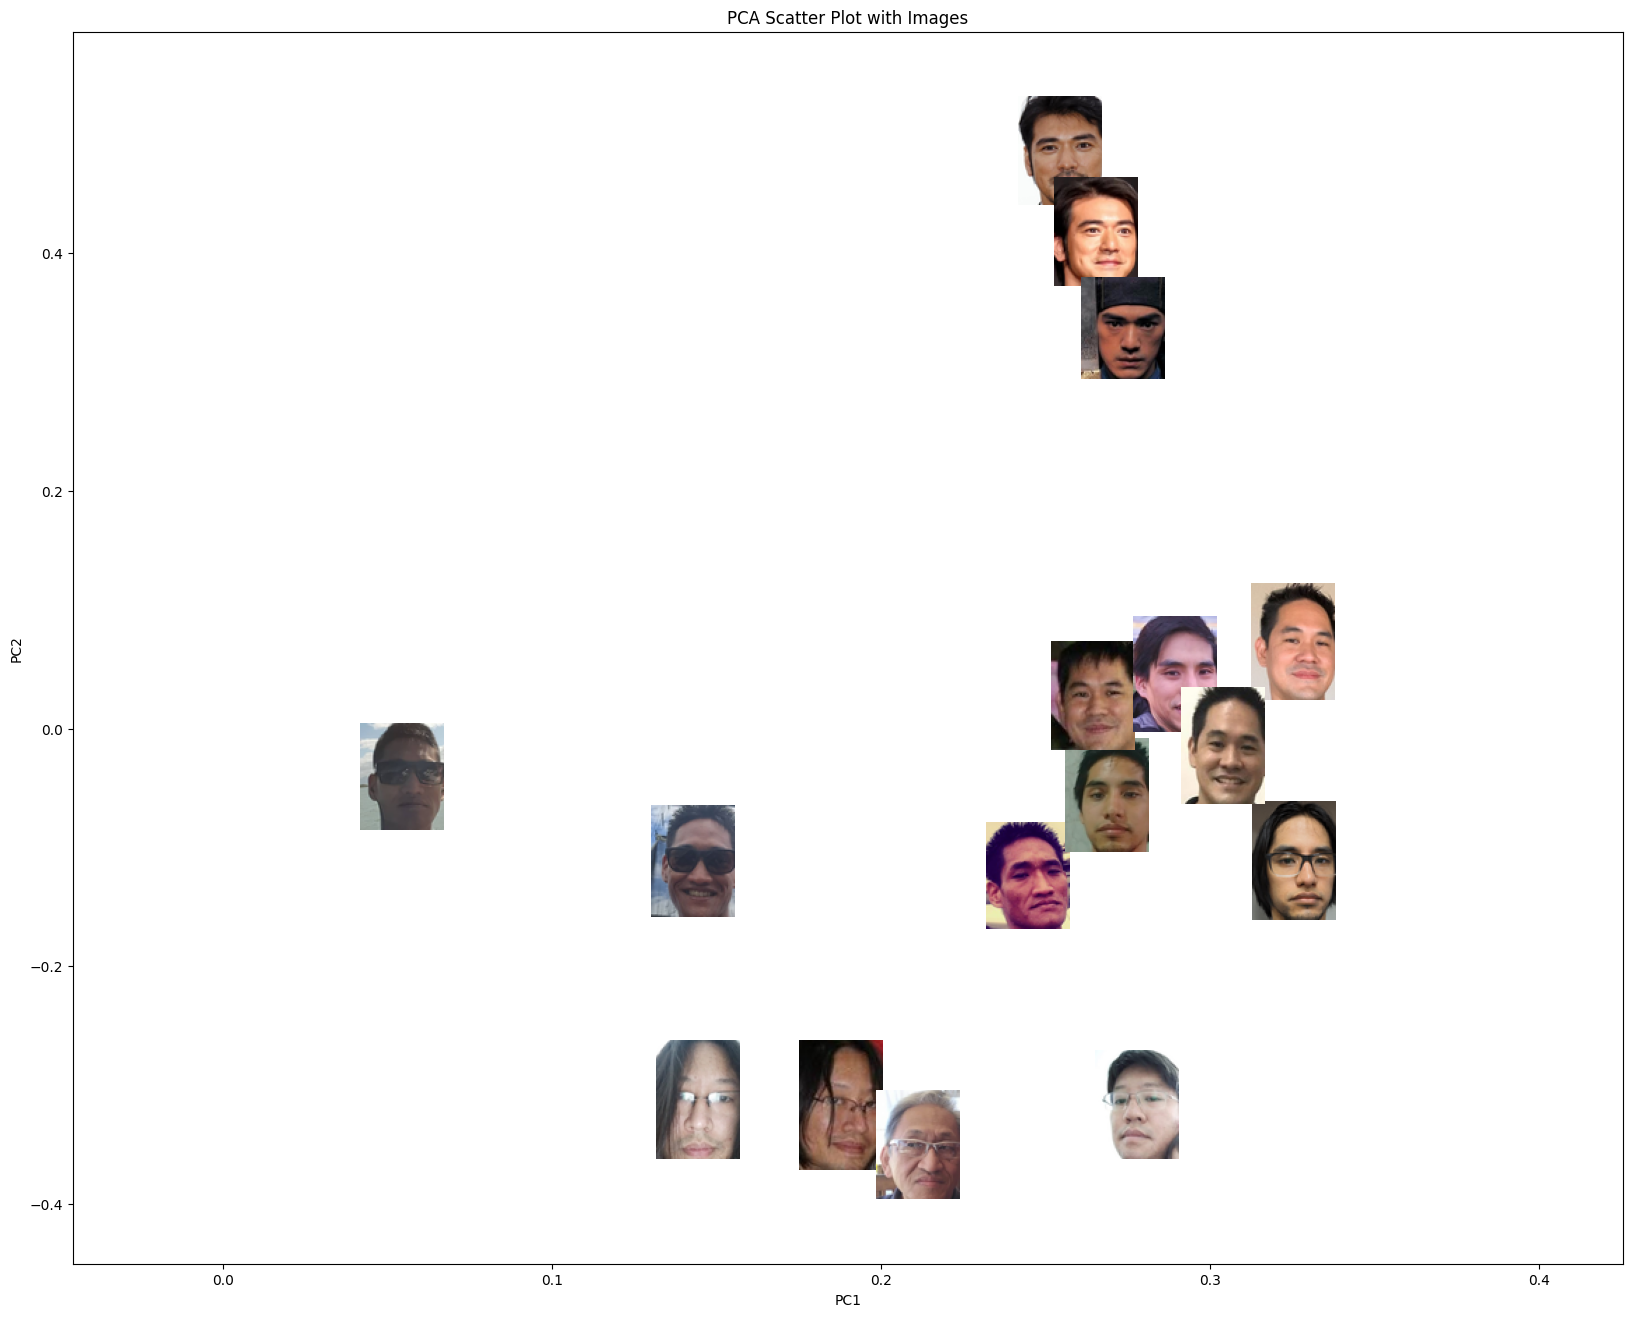

In [ ]:
from matplotlib import pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
# Create a new figure
fig, ax = plt.subplots(figsize=(20, 16))

# Plot the PCA results with images
for i in range(pca_embeddings.shape[0]):
    img_path = imgs[i]
    img = Image.open(img_path)
    # Cut facial area
    x, y, w, h, _, _ = embeddings[img_path.name][0]['facial_area'].values()
    # Buffer 20% of the facial area
    x = max(0, x - w * 0.2)
    y = max(0, y - h * 0.2)
    w = min(img.width, w + w * 0.2)
    h = min(img.height, h + h * 0.2)
    img = img.crop((x, y, x + w, y + h))
    img = img.resize((60,img.height * 60 // img.width), resample = Image.Resampling.LANCZOS)
    imagebox = OffsetImage(img)
    ab = AnnotationBbox(imagebox, (pca_embeddings.loc[i,'PC1'], pca_embeddings.loc[i, 'PC2']), frameon=False)
    ax.add_artist(ab)

# Set labels and title
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA Scatter Plot with Images')
ax.set_xlim(min(pca_embeddings.iloc[:, 0]) - 0.1, max(pca_embeddings.iloc[:, 0]) + 0.1)
ax.set_ylim(min(pca_embeddings.iloc[:, 1]) - 0.1, max(pca_embeddings.iloc[:, 1]) + 0.1)

plt.show()

In [ ]:
# Análise PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
res = pca.fit(all_embeddings.T)

import pandas as pd

pca_embeddings = pd.DataFrame(pca.components_.T)

pca_embeddings.columns = ['PC1', 'PC2', 'PC3']
pca_embeddings

NameError: name 'all_embeddings' is not defined

In [ ]:
# Variabilidade explicada pelos componentes

print(pca.explained_variance_ratio_)

[0.40968935 0.1291244  0.11616026]


NameError: name 'pca_embeddings' is not defined

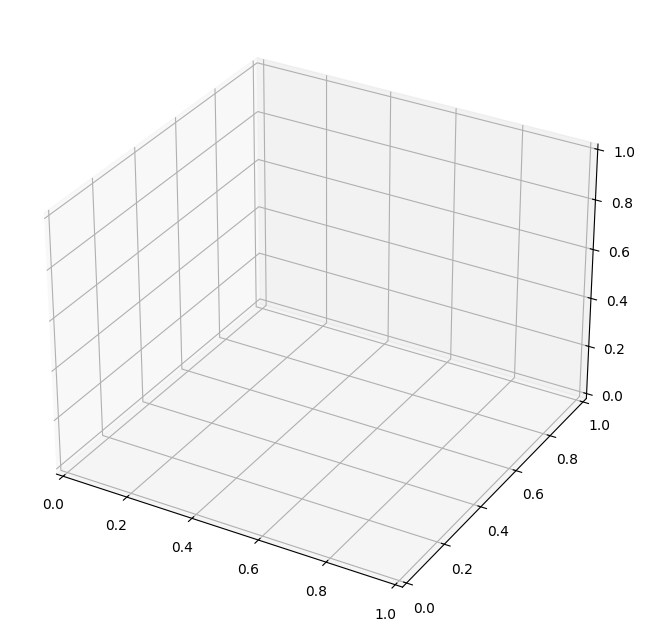

In [ ]:
# prompt: Crie um scatterplot 3D com as imagens nos três componentes principais

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

# Assuming pca_embeddings and imgs are defined as in the previous code

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(pca_embeddings.shape[0]):
    ax.plot(pca_embeddings.loc[i,'PC1'], pca_embeddings.loc[i, 'PC2'], pca_embeddings.loc[i, 'PC3'], marker="o", markersize=20)

    # Use ax.text instead of ax.add_artist(AnnotationBbox) for 3D coordinates
    ax.text(pca_embeddings.loc[i,'PC1'], pca_embeddings.loc[i, 'PC2'], pca_embeddings.loc[i, 'PC3'], img_path.name, fontsize=8)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Scatter Plot with Images')

plt.show()

In [ ]:
import re

In [ ]:
classes = [re.sub(r'\d*.jpg', '', img.name) for img in imgs]

In [ ]:
classes_unicas = np.unique(classes)

In [ ]:
# prompt: Create a color palette for classes_unicas

import re
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'classes_unicas' is defined as in the provided code

# Create a color palette using a colormap
num_classes = len(classes_unicas)
cmap = plt.cm.get_cmap('viridis', num_classes)  # Use 'viridis' or any other colormap

# Create a dictionary to store the color for each class
class_colors = {}
for i, class_name in enumerate(classes_unicas):
    class_colors[class_name] = cmap(i)

# Example usage:
for class_name in classes_unicas:
  print(f"Class: {class_name}, Color: {class_colors[class_name]}")

# You can use 'class_colors' in your plotting code to assign a specific color to each class
# For example:
# plt.scatter(x, y, c=[class_colors[class_name] for class_name in classes], label = classes)

Class: andre, Color: (0.267004, 0.004874, 0.329415, 1.0)
Class: caio, Color: (0.253935, 0.265254, 0.529983, 1.0)
Class: daniel, Color: (0.163625, 0.471133, 0.558148, 1.0)
Class: marcio, Color: (0.134692, 0.658636, 0.517649, 1.0)
Class: shigueo, Color: (0.477504, 0.821444, 0.318195, 1.0)
Class: takeshi, Color: (0.993248, 0.906157, 0.143936, 1.0)


In [ ]:
# prompt: Create the same plot above but interactive

import plotly.graph_objects as go
import pandas as pd
import re

# Assuming pca_embeddings and imgs are defined as in the previous code

fig = go.Figure()



for i in range(pca_embeddings.shape[0]):
    img_path = imgs[i]
    classe = re.sub(r'\d*.jpg', '', img_path.name)



    # ... (code to open, crop, and resize the image as before) ...

    fig.add_trace(go.Scatter3d(
        x=[pca_embeddings.loc[i, 'PC1']],
        y=[pca_embeddings.loc[i, 'PC2']],
        z=[pca_embeddings.loc[i, 'PC3']],
        mode='markers',
        name=classe,
        marker=dict(
            size=10,
            color = class_colors[classe],
            opacity=0.8
        ),
        text=[classe],  # Use image name as hover text
        hoverinfo='text+x+y+z',  # Show image name and coordinates on hover
        showlegend=True  # Ensure legend is shown
    ))


# Customize layout
fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    title='3D PCA Scatter Plot with Images (Interactive)',
    legend=dict(title='Class')  # Add a title for the legend
)

fig.show()

In [ ]:
class_colors

{'andre': (0.267004, 0.004874, 0.329415, 1.0),
 'caio': (0.253935, 0.265254, 0.529983, 1.0),
 'daniel': (0.163625, 0.471133, 0.558148, 1.0),
 'marcio': (0.134692, 0.658636, 0.517649, 1.0),
 'shigueo': (0.477504, 0.821444, 0.318195, 1.0),
 'takeshi': (0.993248, 0.906157, 0.143936, 1.0)}

In [ ]:
# Disconnect runtime
from google.colab import runtime
runtime.unassign()